# 📈 Calculus for Deep Learning

## A Beginner-Friendly, Zero-to-Hero Guide

---

**Welcome!** This notebook will teach you the essential calculus concepts that make neural networks learn. While linear algebra defines *what* computations happen, calculus tells us *how to improve* our model.

### 🎯 What You'll Learn

| Section | Topic | Deep Learning Connection |
|---------|-------|-------------------------|
| 1 | Derivatives | Rate of change, sensitivity |
| 2 | Chain Rule | Backpropagation foundation |
| 3 | Partial Derivatives & Gradients | Multi-variable optimization |
| 4 | Gradient Descent | How neural networks learn |
| 5 | Backpropagation | The heart of deep learning |
| 6 | Vanishing & Exploding Gradients | Why depth is hard, and what fixed it |
| 7 | Gradient Checking | How you know your backprop is correct |
| 8 | Autograd | What PyTorch does for you, and why |

> ✅ **Runs top-to-bottom on Colab** — *Runtime → Run all*. Only NumPy, Matplotlib, SymPy and PyTorch are needed, all pre-installed on Colab. Every derivation in this notebook is verified in code: symbolically with SymPy, numerically with finite differences, and against PyTorch's autograd.

### 🧠 Why Calculus Matters for Deep Learning

```
Training Loop:
1. Forward pass    → Compute predictions
2. Compute loss    → How wrong are we?
3. BACKPROPAGATION → Use CALCULUS to find gradients
4. Update weights  → Move in opposite direction of gradient
5. Repeat!
```

**Neural networks learn by computing derivatives and following gradients downhill!**

---

## ⚙️ Setup

Let's import the libraries we'll use throughout this notebook.

In [1]:
# Core libraries
import numpy as np
import matplotlib.pyplot as plt
# (3-D axes need no special import on modern matplotlib —
#  projection='3d' is enough, as used in Section 3.)

# For beautiful visualizations
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = [10, 6]
plt.rcParams['font.size'] = 12

# Set random seed for reproducibility
np.random.seed(42)

print("✅ Setup complete!")
print(f"NumPy version: {np.__version__}")

Matplotlib is building the font cache; this may take a moment.


✅ Setup complete!
NumPy version: 2.2.6


## 📚 Introduction: The Language of Learning

Before diving into derivatives, let's understand the big picture.

### The Learning Problem

Neural networks have **millions of parameters** (weights and biases). How do we know which direction to adjust them to make better predictions?

**Answer: Derivatives!**

A derivative tells us:
- **Direction**: Should we increase or decrease a weight?
- **Magnitude**: How sensitive is the output to this weight?

Let's see a simple example:

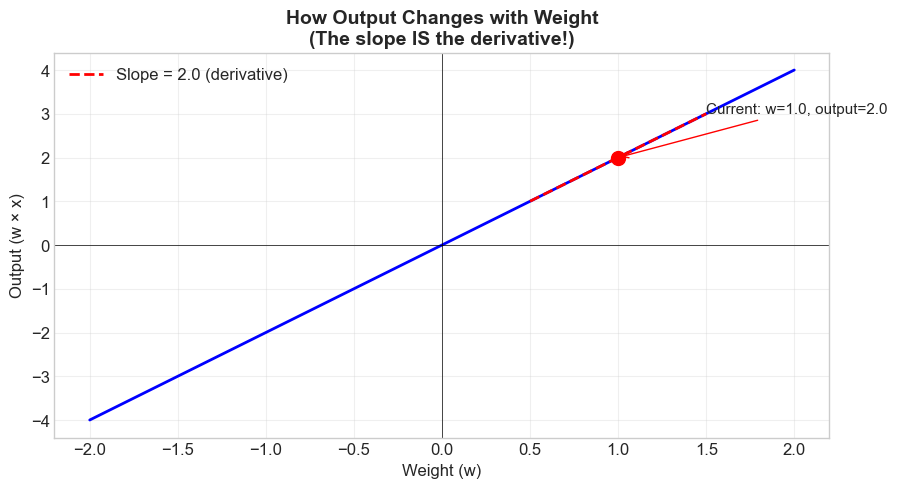

💡 Key Insight:
   If we increase w by a tiny amount ε, output increases by 2.0ε
   The derivative dy/dw = 2.0 tells us exactly this rate of change!


In [2]:
# Simple example: How does changing weight affect output?

def simple_neuron(x, w):
    """A single neuron: output = w * x"""
    return w * x

x = 2.0  # Fixed input
weights = np.linspace(-2, 2, 100)
outputs = [simple_neuron(x, w) for w in weights]

# Plot
plt.figure(figsize=(10, 5))
plt.plot(weights, outputs, 'b-', linewidth=2)
plt.axhline(y=0, color='k', linewidth=0.5)
plt.axvline(x=0, color='k', linewidth=0.5)

# Mark current weight and show slope
w_current = 1.0
y_current = simple_neuron(x, w_current)
plt.scatter([w_current], [y_current], color='red', s=100, zorder=5)
plt.annotate(f'Current: w={w_current}, output={y_current}',
             xy=(w_current, y_current), xytext=(w_current+0.5, y_current+1),
             fontsize=11, arrowprops=dict(arrowstyle='->', color='red'))

# Draw tangent line (the derivative!)
slope = x  # dy/dw = x (the derivative)
tangent_x = np.array([w_current-0.5, w_current+0.5])
tangent_y = y_current + slope * (tangent_x - w_current)
plt.plot(tangent_x, tangent_y, 'r--', linewidth=2, label=f'Slope = {slope} (derivative)')

plt.xlabel('Weight (w)', fontsize=12)
plt.ylabel('Output (w × x)', fontsize=12)
plt.title('How Output Changes with Weight\n(The slope IS the derivative!)', fontsize=14, fontweight='bold')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

print("💡 Key Insight:")
print(f"   If we increase w by a tiny amount ε, output increases by {x}ε")
print(f"   The derivative dy/dw = {x} tells us exactly this rate of change!")

<div style="background-color: #e7f3fe; border-left: 5px solid #2196F3; padding: 14px; border-radius: 8px; margin: 10px 0;">

### 📊 What this shows

**Axes.** Horizontal: the weight $w$ we are free to choose. Vertical: what the neuron then outputs, $w \times x$ with the input pinned at $x = 2$.

**The blue line** is the whole space of possibilities — every weight and the output it produces. Because the neuron is $w \cdot x$ with $x$ fixed, that relationship is a straight line of slope $2$.

**The red dot** marks where we happen to be sitting ($w = 1$). **The red dashed line** is the tangent at that point, and its slope *is* the derivative $\frac{d}{dw}(wx) = x = 2$.

**What to take away:** the derivative answers a *decision* question — "if I nudge this weight up by a hair, does the output go up or down, and by how much?" Here: up, at twice the rate of the nudge. That single number is the entire signal a network uses to know which way to move a weight.

**The common misread:** the slope is $2$ because the *input* is $2$ — not because the weight is $1$. Change the input and the line tilts; change the weight and you only slide along it. That is why a neuron's gradient depends on the data flowing through it.

</div>


---

### 🎓 What's Next?

Now that you've seen the intuition, we'll systematically build up:

1. **Derivatives** - The fundamental concept
2. **Chain Rule** - Derivatives of composed functions
3. **Gradients** - Derivatives with multiple variables
4. **Gradient Descent** - Using derivatives to learn
5. **Backpropagation** - Efficient gradient computation

Let's begin! 🚀

---

## 1️⃣ Derivatives: The Foundation

A **derivative** measures how much a function's output changes when its input changes by a tiny amount.

$$\frac{df}{dx} = \lim_{h \to 0} \frac{f(x + h) - f(x)}{h}$$

### Common Derivatives in Deep Learning

| Function | Derivative | Deep Learning Use |
|----------|------------|-------------------|
| f(x) = x² | f'(x) = 2x | MSE loss |
| f(x) = eˣ | f'(x) = eˣ | Softmax |
| f(x) = ln(x) | f'(x) = 1/x | Cross-entropy loss |
| f(x) = sigmoid | f'(x) = f(x)(1-f(x)) | Activation |
| f(x) = ReLU | f'(x) = 0 or 1 | Activation |

### 🔍 Where does that limit definition come from?

The formula above is not a rule to memorise — it is a picture written in symbols. Let us build it.

**The question:** *"If I nudge the input a little, how much does the output move?"*

**Step 1 — measure an actual change.** Move from $x$ to $x+h$. The output moves from $f(x)$ to $f(x+h)$. So

$$ \text{rise} = f(x+h) - f(x), \qquad \text{run} = h $$

**Step 2 — turn it into a rate.** A change of 6 means nothing until you know it took a step of 2 or a step of 200. Divide:

$$ \text{average rate of change} = \frac{f(x+h) - f(x)}{h} \qquad \text{(rise over run — the slope of a straight line through two points)} $$

**Step 3 — shrink the step.** That slope is the average over a *stretch* of the curve. We want the rate *at a point*, so we let the second point slide into the first:

$$ \frac{df}{dx} = \lim_{h \to 0} \frac{f(x+h) - f(x)}{h} \qquad \text{(the limit turns a chord into a tangent)} $$

That is the whole idea: **a derivative is a slope you measured over a step so small the curve had no time to bend.**

### ✍️ Do it once by hand: $f(x) = x^2$

| Step | Working | Why |
|---|---|---|
| 1 | $f(x+h) = (x+h)^2 = x^2 + 2xh + h^2$ | expand the square |
| 2 | $f(x+h) - f(x) = 2xh + h^2$ | the $x^2$ terms cancel |
| 3 | $\dfrac{2xh + h^2}{h} = 2x + h$ | divide by $h$ — legal because $h \neq 0$ *on the way to* the limit |
| 4 | $\lim_{h\to 0} (2x + h) = 2x$ | now $h$ may safely go to zero |

$$ \boxed{\dfrac{d}{dx}x^2 = 2x} $$

<div style="background-color: #fff3cd; border-left: 5px solid #ffc107; padding: 14px; border-radius: 8px; margin: 10px 0;">

**⚠️ The subtlety worth noticing.** In step 3 we divided by $h$; in step 4 we set $h \to 0$. That looks illegal — and it is exactly what took mathematicians 150 years to make rigorous. The resolution: we never divide by zero. We divide by a *non-zero* $h$, simplify, and only then ask what the simplified expression approaches. The cancellation in step 2 is what makes this possible.

</div>

The next cell checks step 4 numerically: it computes the slope with a genuinely tiny $h$ and compares it to $2x$.


In [3]:
# Computing derivatives numerically vs analytically
def numerical_derivative(f, x, h=1e-5):
    """Compute derivative using finite differences"""
    return (f(x + h) - f(x - h)) / (2 * h)  # Central difference (more accurate)

# Example: f(x) = x²
def f(x):
    return x ** 2

def f_derivative_analytical(x):
    """Analytical derivative: d/dx(x²) = 2x"""
    return 2 * x

x_test = 3.0
numerical = numerical_derivative(f, x_test)
analytical = f_derivative_analytical(x_test)

print("📐 Computing Derivatives")
print("="*40)
print(f"Function: f(x) = x²")
print(f"At x = {x_test}:")
print(f"  f({x_test}) = {f(x_test)}")
print(f"\n  Numerical derivative:  {numerical:.6f}")
print(f"  Analytical derivative: {analytical:.6f}")
print(f"  Difference: {abs(numerical - analytical):.10f}")
print("\n✅ They match! (tiny error is from numerical approximation)")

📐 Computing Derivatives
Function: f(x) = x²
At x = 3.0:
  f(3.0) = 9.0

  Numerical derivative:  6.000000
  Analytical derivative: 6.000000
  Difference: 0.0000000000

✅ They match! (tiny error is from numerical approximation)


### 🔬 Now let a computer algebra system check our hand-derivations

We derived two results by hand: $\frac{d}{dx}x^2 = 2x$ and $\sigma' = \sigma(1-\sigma)$. Numerical agreement (above) is good evidence; **symbolic** agreement is proof at the level of the algebra itself.

`sympy` differentiates the way you did on paper — by manipulating symbols, not by plugging in numbers — so if it agrees, our steps were valid for *every* $x$, not just the one we tested.


In [4]:
# ── Verifying our derivations symbolically with SymPy ──────────────────────
# New API in this cell:
#   sp.symbols('x')  -> creates a symbolic variable (an unknown, not a number)
#   sp.diff(expr, x) -> differentiates expr with respect to x, algebraically
#   sp.simplify(e)   -> rewrites e in a canonical simplified form
#   expr.subs(x, v)  -> substitutes a value in;  float(...) evaluates it
import sympy as sp

x_sym = sp.symbols('x', real=True)          # a symbol, not a value

# ── Step 1 ── the power rule result we derived from the limit definition
expr_square = x_sym**2
print("d/dx [x^2]      =", sp.diff(expr_square, x_sym), "      (we derived 2*x)")

# ── Step 2 ── the sigmoid derivative, the long way and the short way
sigma_sym   = 1 / (1 + sp.exp(-x_sym))              # the definition
deriv_auto  = sp.diff(sigma_sym, x_sym)             # what SymPy computes
deriv_ours  = sigma_sym * (1 - sigma_sym)           # what we derived by hand

# sp.simplify on the DIFFERENCE is the honest test: it should collapse to 0.
difference = sp.simplify(deriv_auto - deriv_ours)
print("sigma'(x) - [sigma(1-sigma)] =", difference, "  <- 0 means our derivation is exact")

# ── Step 3 ── a preview of the rule we'll meet in Section 2, on y = (3x+2)^2.
#              For now just note the answer; Section 2 derives WHY.
expr_chain = (3*x_sym + 2)**2
print("d/dx [(3x+2)^2] =", sp.expand(sp.diff(expr_chain, x_sym)),
      "   (Section 2 will show this is 6*(3x+2) = 18x + 12)")

# ── Step 4 ── the ceiling on the sigmoid gradient, found by calculus itself
#   maximise sigma' by setting its own derivative to zero
critical = sp.solve(sp.diff(deriv_ours, x_sym), x_sym)
peak     = sp.simplify(deriv_ours.subs(x_sym, critical[0]))
print(f"\nsigma' is largest at x = {critical[0]}, where it equals {peak} = {float(peak)}")
print("So one sigmoid layer multiplies an incoming gradient by AT MOST 0.25.")
print("Section 6 measures what that does across many layers.")


d/dx [x^2]      = 2*x       (we derived 2*x)


sigma'(x) - [sigma(1-sigma)] = 0   <- 0 means our derivation is exact
d/dx [(3x+2)^2] = 18*x + 12    (Section 2 will show this is 6*(3x+2) = 18x + 12)

sigma' is largest at x = 0, where it equals 1/4 = 0.25
So one sigmoid layer multiplies an incoming gradient by AT MOST 0.25.
Section 6 measures what that does across many layers.


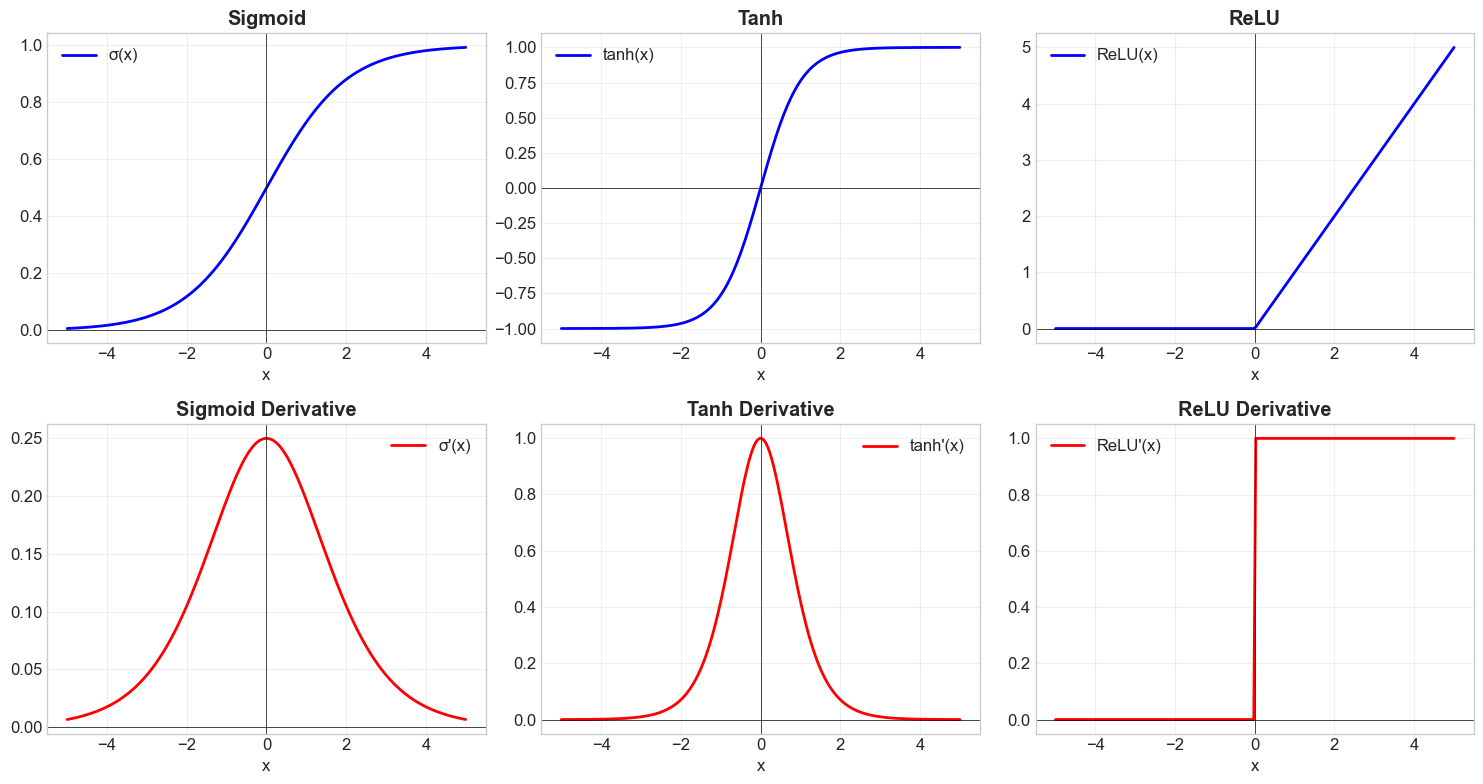

💡 Key Insights:
   • Sigmoid/Tanh: Derivatives → 0 for large |x| (vanishing gradient problem!)
   • ReLU: Derivative is 0 or 1 (no vanishing gradient for x > 0)
   • This is why ReLU became the default activation in modern networks!


In [5]:
# Visualizing activation functions and their derivatives
fig, axes = plt.subplots(2, 3, figsize=(15, 8))

x = np.linspace(-5, 5, 200)

# Sigmoid
sigmoid = 1 / (1 + np.exp(-x))
sigmoid_deriv = sigmoid * (1 - sigmoid)
axes[0, 0].plot(x, sigmoid, 'b-', linewidth=2, label='σ(x)')
axes[0, 0].set_title('Sigmoid', fontweight='bold')
axes[1, 0].plot(x, sigmoid_deriv, 'r-', linewidth=2, label="σ'(x)")
axes[1, 0].set_title("Sigmoid Derivative", fontweight='bold')

# Tanh
tanh = np.tanh(x)
tanh_deriv = 1 - tanh**2
axes[0, 1].plot(x, tanh, 'b-', linewidth=2, label='tanh(x)')
axes[0, 1].set_title('Tanh', fontweight='bold')
axes[1, 1].plot(x, tanh_deriv, 'r-', linewidth=2, label="tanh'(x)")
axes[1, 1].set_title("Tanh Derivative", fontweight='bold')

# ReLU
relu = np.maximum(0, x)
relu_deriv = (x > 0).astype(float)
axes[0, 2].plot(x, relu, 'b-', linewidth=2, label='ReLU(x)')
axes[0, 2].set_title('ReLU', fontweight='bold')
axes[1, 2].plot(x, relu_deriv, 'r-', linewidth=2, label="ReLU'(x)")
axes[1, 2].set_title("ReLU Derivative", fontweight='bold')

for ax in axes.flat:
    ax.axhline(y=0, color='k', linewidth=0.5)
    ax.axvline(x=0, color='k', linewidth=0.5)
    ax.grid(True, alpha=0.3)
    ax.legend()
    ax.set_xlabel('x')

plt.tight_layout()
plt.show()

print("💡 Key Insights:")
print("   • Sigmoid/Tanh: Derivatives → 0 for large |x| (vanishing gradient problem!)")
print("   • ReLU: Derivative is 0 or 1 (no vanishing gradient for x > 0)")
print("   • This is why ReLU became the default activation in modern networks!")

<div style="background-color: #e7f3fe; border-left: 5px solid #2196F3; padding: 14px; border-radius: 8px; margin: 10px 0;">

### 📊 What this shows

**Layout.** Six panels in two rows. **Top row:** three activation functions — sigmoid, tanh, ReLU. **Bottom row:** the derivative of the function directly above it. Same $x$-axis throughout, running from $-5$ to $5$.

**Read the bottom row — that is the row that decides whether a deep network trains.** During backpropagation, the gradient arriving at a layer gets **multiplied** by that layer's derivative.

| Panel | Peak of the derivative | Consequence |
|---|---|---|
| Sigmoid $\sigma'$ | $0.25$ at $x=0$, falling to $\approx 0$ by $\lvert x\rvert > 5$ | every layer shrinks the gradient by at least $4\times$ |
| Tanh $1 - \tanh^2$ | $1.0$ at $x=0$, also collapsing at the edges | better centred, same saturation problem |
| ReLU | exactly $1$ for $x > 0$, exactly $0$ for $x < 0$ | passes the gradient through untouched — or kills it dead |

**What to look for:** the *flat regions* on either side of the sigmoid and tanh derivative curves. A neuron that lands there is **saturated** — its derivative is nearly zero, so it multiplies the gradient by nearly zero, and every layer beneath it stops learning. That is the vanishing-gradient problem, and we measure it in Section 6.

**The common misread:** ReLU's derivative being $1$ does not mean "no vanishing gradient ever." It means the *activation* does not shrink the gradient; the weight matrices still can. It also introduces the opposite failure — a unit stuck at $x<0$ has derivative exactly $0$ and may never recover (a "dead ReLU").

</div>


### 🎯 The one derivative you must be able to derive: $\sigma'(x) = \sigma(x)\,(1 - \sigma(x))$

The plot above shows the sigmoid's derivative, and the backpropagation code later in this notebook *uses* it — so let us actually derive it rather than take it on faith. It is also a favourite interview question, precisely because the answer is so clean.

**Setup.** The sigmoid is

$$ \sigma(x) = \frac{1}{1 + e^{-x}} = \left(1 + e^{-x}\right)^{-1} $$

**Step 1 — differentiate with the power rule and the chain rule.**

$$ \sigma'(x) = -1 \cdot \left(1 + e^{-x}\right)^{-2} \cdot \frac{d}{dx}\left(1 + e^{-x}\right) \qquad \text{(power rule } \tfrac{d}{du}u^{-1} = -u^{-2}\text{, then chain rule for the inner } u = 1+e^{-x}) $$

**Step 2 — differentiate the inside.**

$$ \frac{d}{dx}\left(1 + e^{-x}\right) = -e^{-x} \qquad \text{(the 1 is constant; } \tfrac{d}{dx}e^{-x} = -e^{-x} \text{ by the chain rule)} $$

**Step 3 — put them together; the two minus signs cancel.**

$$ \sigma'(x) = \frac{e^{-x}}{\left(1 + e^{-x}\right)^{2}} \qquad \text{(substituting step 2 into step 1)} $$

**Step 4 — the trick: split the fraction so each piece is a sigmoid.**

$$ \frac{e^{-x}}{\left(1+e^{-x}\right)^{2}} = \underbrace{\frac{1}{1+e^{-x}}}_{\textstyle \sigma(x)} \cdot \underbrace{\frac{e^{-x}}{1+e^{-x}}}_{\textstyle ?} \qquad \text{(just regrouping the same product)} $$

**Step 5 — recognise the second factor.**

$$ \frac{e^{-x}}{1+e^{-x}} = \frac{\left(1 + e^{-x}\right) - 1}{1+e^{-x}} = 1 - \frac{1}{1+e^{-x}} = 1 - \sigma(x) \qquad \text{(add and subtract 1 in the numerator, then split)} $$

**Result.**

$$ \boxed{\;\sigma'(x) = \sigma(x)\,\bigl(1 - \sigma(x)\bigr)\;} $$

<div style="background-color: #d4edda; border-left: 5px solid #28a745; padding: 14px; border-radius: 8px; margin: 10px 0;">

**✅ Why this matters so much in practice.** The derivative is expressed **entirely in terms of the value you already computed**. During the forward pass you stored $a = \sigma(z)$; the backward pass then needs no exponentials at all — just `a * (1 - a)`. Look for exactly that line in the backpropagation code in Section 5. This is the single reason sigmoid was the default activation for decades.

And it explains the vanishing-gradient problem you can see in the plot: $\sigma \in (0,1)$, so $\sigma(1-\sigma) \le \tfrac14$, with the maximum at $x=0$. Every sigmoid layer multiplies the gradient by **at most 0.25**. We measure the damage in Section 6.

</div>


---

✅ **Section 1 Complete!** You now understand:
- Derivatives measure rate of change
- Numerical vs analytical computation
- Why ReLU helps with vanishing gradients

Next: **Chain Rule** - the backbone of backpropagation!

---

## 2️⃣ The Chain Rule - Heart of Backpropagation

The **chain rule** tells us how to take derivatives of composed functions.

If `y = f(g(x))`, then:

$$\frac{dy}{dx} = \frac{dy}{dg} \cdot \frac{dg}{dx}$$

**This is EXACTLY how backpropagation works!** Gradients flow backward through each layer.

```
Input → Layer 1 → Layer 2 → Layer 3 → Loss
         ↑          ↑          ↑
         │          │          │
    ← dL/dW1 ← dL/dW2 ← dL/dW3 ←
    
    (Chain rule multiplies gradients backward!)
```

### 🔍 Why the chain rule is true (and why it looks like cancelling fractions)

The formula $\frac{dy}{dx} = \frac{dy}{dg}\cdot\frac{dg}{dx}$ looks like the $dg$'s simply cancel. That is a good *mnemonic* and a bad *proof* — but there is a real argument underneath, and it is short.

**The intuition — a chain of gears.**

> Turn gear $x$. It drives gear $g$ **3 times as fast**. Gear $g$ drives gear $y$ **2 times as fast**. So turning $x$ turns $y$ $3 \times 2 = 6$ times as fast.

Rates *multiply* along a chain. That is the entire content of the chain rule.

**The argument — one step, made honest.**

Nudge $x$ by a small $h$. Two things happen in sequence:

| Step | Working | Why |
|---|---|---|
| 1 | $g$ changes by $\Delta g = g(x+h) - g(x)$ | definition of the change in the inner function |
| 2 | $y$ changes by $\Delta y = f(g + \Delta g) - f(g)$ | the outer function sees only that change |
| 3 | $\dfrac{\Delta y}{h} = \dfrac{\Delta y}{\Delta g}\cdot\dfrac{\Delta g}{h}$ | multiply and divide by $\Delta g$ — an identity, not magic |
| 4 | as $h \to 0$: $\Delta g \to 0$ too | $g$ is differentiable, hence continuous |
| 5 | $\dfrac{\Delta y}{\Delta g} \to f'(g)$ and $\dfrac{\Delta g}{h} \to g'(x)$ | each factor is now a difference quotient at a point |

$$ \boxed{\;\frac{dy}{dx} = f'\bigl(g(x)\bigr)\cdot g'(x)\;} $$

<div style="background-color: #e7f3fe; border-left: 5px solid #2196F3; padding: 14px; border-radius: 8px; margin: 10px 0;">

**🧠 The one gap, named honestly.** Step 3 divides by $\Delta g$, which is illegal if $\Delta g = 0$ for some nudges (imagine a function that is flat in patches). The full proof patches this by defining a helper function that equals $\Delta y / \Delta g$ when $\Delta g \neq 0$ and $f'(g)$ when it is zero, then showing that helper is continuous. The idea is unchanged — **rates multiply along a chain** — so we note the gap rather than hide it.

</div>

**Why a deep network is just this, repeated.** A network *is* a composition: $L\bigl(f_3(f_2(f_1(x)))\bigr)$. Apply the rule three times and you get a product of three local derivatives. Backpropagation is nothing more than **evaluating that product from the left**, so each factor is computed once and reused.


In [6]:
# Chain Rule Example: y = (3x + 2)²
# Let g(x) = 3x + 2, and y = g²
# dy/dx = dy/dg * dg/dx = 2g * 3 = 6(3x + 2)

def g(x):
    return 3 * x + 2

def y(x):
    return g(x) ** 2

# Derivatives
def dg_dx(x):
    return 3  # d/dx(3x + 2) = 3

def dy_dg(x):
    return 2 * g(x)  # d/dg(g²) = 2g

def dy_dx_chain_rule(x):
    return dy_dg(x) * dg_dx(x)  # Chain rule!

x_test = 2.0
print("⛓️ Chain Rule Example: y = (3x + 2)²")
print("="*45)
print(f"x = {x_test}")
print(f"g(x) = 3x + 2 = {g(x_test)}")
print(f"y = g² = {y(x_test)}")
print(f"\nUsing Chain Rule:")
print(f"  dg/dx = 3")
print(f"  dy/dg = 2g = 2 × {g(x_test)} = {dy_dg(x_test)}")
print(f"  dy/dx = dy/dg × dg/dx = {dy_dg(x_test)} × {dg_dx(x_test)} = {dy_dx_chain_rule(x_test)}")
print(f"\nVerify numerically: {numerical_derivative(y, x_test):.4f}")
print(f"✅ Match!")

⛓️ Chain Rule Example: y = (3x + 2)²
x = 2.0
g(x) = 3x + 2 = 8.0
y = g² = 64.0

Using Chain Rule:
  dg/dx = 3
  dy/dg = 2g = 2 × 8.0 = 16.0
  dy/dx = dy/dg × dg/dx = 16.0 × 3 = 48.0

Verify numerically: 48.0000
✅ Match!


In [7]:
# Deep Learning Example: Chain Rule Through a Mini Network
# x → [w1] → z1 → [sigmoid] → a1 → [w2] → z2 → [MSE loss] → L

def forward_pass(x, w1, w2, y_true):
    """Forward pass through mini network"""
    # Layer 1
    z1 = w1 * x
    a1 = 1 / (1 + np.exp(-z1))  # Sigmoid

    # Layer 2
    z2 = w2 * a1
    prediction = z2

    # Loss (MSE)
    loss = (prediction - y_true) ** 2

    return z1, a1, z2, prediction, loss

def backward_pass(x, w1, w2, y_true, z1, a1, z2, prediction):
    """Backward pass using chain rule"""
    # dL/d(prediction) = 2(prediction - y_true)
    dL_dpred = 2 * (prediction - y_true)

    # dL/dz2 = dL/dpred * dpred/dz2 = dL/dpred * 1
    dL_dz2 = dL_dpred

    # dL/dw2 = dL/dz2 * dz2/dw2 = dL/dz2 * a1
    dL_dw2 = dL_dz2 * a1

    # dL/da1 = dL/dz2 * dz2/da1 = dL/dz2 * w2
    dL_da1 = dL_dz2 * w2

    # dL/dz1 = dL/da1 * da1/dz1 = dL/da1 * sigmoid'(z1)
    sigmoid_deriv = a1 * (1 - a1)  # Sigmoid derivative
    dL_dz1 = dL_da1 * sigmoid_deriv

    # dL/dw1 = dL/dz1 * dz1/dw1 = dL/dz1 * x
    dL_dw1 = dL_dz1 * x

    return dL_dw1, dL_dw2

# Test
x = 2.0
w1 = 0.5
w2 = 0.8
y_true = 1.0

z1, a1, z2, pred, loss = forward_pass(x, w1, w2, y_true)
dL_dw1, dL_dw2 = backward_pass(x, w1, w2, y_true, z1, a1, z2, pred)

print("🧠 Chain Rule Through a Neural Network")
print("="*50)
print("Network: x → w1 → sigmoid → w2 → MSE Loss")
print(f"\nForward Pass:")
print(f"  x = {x}")
print(f"  z1 = w1 × x = {w1} × {x} = {z1}")
print(f"  a1 = sigmoid(z1) = {a1:.4f}")
print(f"  z2 = w2 × a1 = {w2} × {a1:.4f} = {z2:.4f}")
print(f"  prediction = {pred:.4f}")
print(f"  loss = (pred - y)² = ({pred:.4f} - {y_true})² = {loss:.4f}")

print(f"\nBackward Pass (Chain Rule!):")
print(f"  dL/dw2 = {dL_dw2:.4f}")
print(f"  dL/dw1 = {dL_dw1:.4f}")

print("\n💡 These gradients tell us how to adjust w1 and w2 to reduce loss!")

🧠 Chain Rule Through a Neural Network
Network: x → w1 → sigmoid → w2 → MSE Loss

Forward Pass:
  x = 2.0
  z1 = w1 × x = 0.5 × 2.0 = 1.0
  a1 = sigmoid(z1) = 0.7311
  z2 = w2 × a1 = 0.8 × 0.7311 = 0.5848
  prediction = 0.5848
  loss = (pred - y)² = (0.5848 - 1.0)² = 0.1724

Backward Pass (Chain Rule!):
  dL/dw2 = -0.6070
  dL/dw1 = -0.2612

💡 These gradients tell us how to adjust w1 and w2 to reduce loss!


---

✅ **Section 2 Complete!** You now understand:
- Chain rule for composed functions
- How gradients flow backward through layers
- The mathematical foundation of backpropagation

Next: **Partial Derivatives & Gradients** - multiple variables!

---

## 3️⃣ Partial Derivatives & Gradients

Neural networks have **millions of parameters**. We need derivatives with respect to EACH one!

### Partial Derivative

A **partial derivative** measures how a function changes with respect to ONE variable, treating others as constants.

$$\frac{\partial f}{\partial x} = \text{derivative of } f \text{ treating everything except } x \text{ as constant}$$

### Gradient

The **gradient** is a vector of ALL partial derivatives:

$$\nabla f = \begin{bmatrix} \frac{\partial f}{\partial x_1} \\ \frac{\partial f}{\partial x_2} \\ \vdots \\ \frac{\partial f}{\partial x_n} \end{bmatrix}$$

**Key property**: The gradient points in the direction of **steepest increase**!

### 🔍 Why does the gradient point *uphill*? (the claim above, actually justified)

"The gradient points in the direction of steepest increase" is the load-bearing claim of all of deep learning — every weight update leans on it — so it deserves more than an assertion.

**Step 1 — ask what "the slope in a direction" even means.** Pick a unit direction $\mathbf{u}$ (so $\|\mathbf{u}\| = 1$). Walk from $\mathbf{x}$ a tiny distance $t$ that way. The rate of change you feel is the **directional derivative**

$$ D_{\mathbf{u}} f = \lim_{t \to 0} \frac{f(\mathbf{x} + t\mathbf{u}) - f(\mathbf{x})}{t} $$

**Step 2 — a multivariable chain rule turns that into a dot product.** Moving along $\mathbf{u}$ changes each coordinate at rate $u_i$, and each coordinate contributes $\partial f/\partial x_i$, so the contributions add:

$$ D_{\mathbf{u}} f = \sum_i \frac{\partial f}{\partial x_i}\,u_i = \nabla f \cdot \mathbf{u} \qquad \text{(that sum is exactly the definition of a dot product)} $$

**Step 3 — ask which $\mathbf{u}$ makes that biggest.** Use the geometric form of the dot product:

$$ \nabla f \cdot \mathbf{u} = \|\nabla f\|\,\|\mathbf{u}\|\cos\theta = \|\nabla f\|\cos\theta \qquad \text{(since } \|\mathbf{u}\| = 1\text{)} $$

where $\theta$ is the angle between $\mathbf{u}$ and $\nabla f$. Now everything is fixed except $\cos\theta$, and

$$ \cos\theta \text{ is largest } (= 1) \text{ exactly when } \theta = 0 \qquad \text{i.e. when } \mathbf{u} \text{ points along } \nabla f $$

**Three conclusions fall out at once:**

| Direction | $\cos\theta$ | Rate of change | Meaning |
|---|---|---|---|
| along $+\nabla f$ | $+1$ | $+\|\nabla f\|$ | **steepest ascent** — fastest way up |
| along $-\nabla f$ | $-1$ | $-\|\nabla f\|$ | **steepest descent** — this is why we subtract it |
| perpendicular to $\nabla f$ | $0$ | $0$ | you are walking along a **contour line** |

<div style="background-color: #d4edda; border-left: 5px solid #28a745; padding: 14px; border-radius: 8px; margin: 10px 0;">

**✅ Three things you just earned.** (1) The weight-update rule $\mathbf{w} \leftarrow \mathbf{w} - \eta\nabla L$ has a *reason*: $-\nabla L$ is provably the fastest way down. (2) $\|\nabla f\|$ is not decoration — it is literally the steepness, which is why "gradient norm" is a training diagnostic. (3) The gradient is **perpendicular to the contour lines**, which is why the arrows in the contour plot in Section 3 cross the rings at right angles. Watch for it.

</div>


In [8]:
# Example: f(x, y) = x² + 2xy + y²
def f(x, y):
    return x**2 + 2*x*y + y**2

# Partial derivatives (computed analytically)
def df_dx(x, y):
    """∂f/∂x = 2x + 2y (treat y as constant)"""
    return 2*x + 2*y

def df_dy(x, y):
    """∂f/∂y = 2x + 2y (treat x as constant)"""
    return 2*x + 2*y

def gradient(x, y):
    """Gradient = [∂f/∂x, ∂f/∂y]"""
    return np.array([df_dx(x, y), df_dy(x, y)])

# Test at point (1, 2)
x, y = 1.0, 2.0
print("📐 Partial Derivatives and Gradient")
print("="*45)
print(f"Function: f(x, y) = x² + 2xy + y²")
print(f"Point: (x, y) = ({x}, {y})")
print(f"f({x}, {y}) = {f(x, y)}")
print(f"\n∂f/∂x = 2x + 2y = {df_dx(x, y)}")
print(f"∂f/∂y = 2x + 2y = {df_dy(x, y)}")
print(f"\nGradient ∇f = [{df_dx(x, y)}, {df_dy(x, y)}]")
print(f"Gradient magnitude: {np.linalg.norm(gradient(x, y)):.2f}")

print("\n💡 The gradient points toward steepest ascent!")
print("   To minimize, go in the OPPOSITE direction (negative gradient).")

📐 Partial Derivatives and Gradient
Function: f(x, y) = x² + 2xy + y²
Point: (x, y) = (1.0, 2.0)
f(1.0, 2.0) = 9.0

∂f/∂x = 2x + 2y = 6.0
∂f/∂y = 2x + 2y = 6.0

Gradient ∇f = [6.0, 6.0]
Gradient magnitude: 8.49

💡 The gradient points toward steepest ascent!
   To minimize, go in the OPPOSITE direction (negative gradient).


/var/folders/mz/9z30xzjs3sd9h00px0g18mqr0000gn/T/ipykernel_97653/1023269322.py:45: UserWarning: Glyph 8322 (\N{SUBSCRIPT TWO}) missing from font(s) Arial.
  plt.tight_layout()
/var/folders/mz/9z30xzjs3sd9h00px0g18mqr0000gn/T/ipykernel_97653/1023269322.py:45: UserWarning: Glyph 8321 (\N{SUBSCRIPT ONE}) missing from font(s) Arial.
  plt.tight_layout()
/Users/anitaagasaveeran/Desktop/MSSE_Fall2026/CMPE255/Assignment2/.venv/lib/python3.12/site-packages/IPython/core/pylabtools.py:158: UserWarning: Glyph 8321 (\N{SUBSCRIPT ONE}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/anitaagasaveeran/Desktop/MSSE_Fall2026/CMPE255/Assignment2/.venv/lib/python3.12/site-packages/IPython/core/pylabtools.py:158: UserWarning: Glyph 8322 (\N{SUBSCRIPT TWO}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


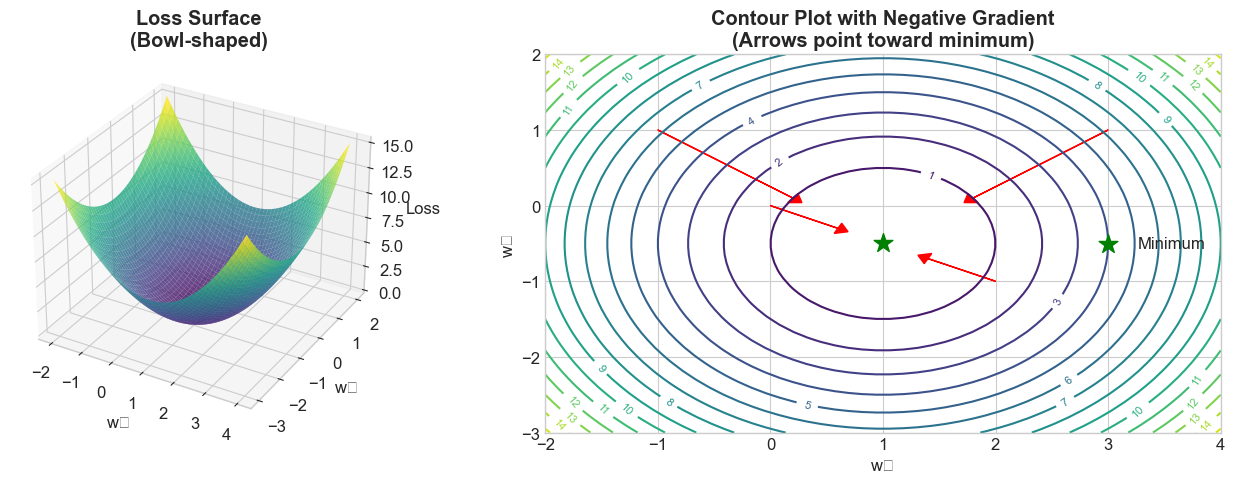

💡 Key Insight: Gradient descent follows the negative gradient downhill!
   Red arrows show the direction we should move to reduce loss.


In [9]:
# Visualizing gradient on a loss surface
fig = plt.figure(figsize=(14, 5))

# Loss function (bowl shape)
def loss(w1, w2):
    return (w1 - 1)**2 + (w2 + 0.5)**2

def loss_gradient(w1, w2):
    return np.array([2*(w1 - 1), 2*(w2 + 0.5)])

# Create grid
w1_range = np.linspace(-2, 4, 50)
w2_range = np.linspace(-3, 2, 50)
W1, W2 = np.meshgrid(w1_range, w2_range)
L = loss(W1, W2)

# 3D surface
ax1 = fig.add_subplot(121, projection='3d')
ax1.plot_surface(W1, W2, L, cmap='viridis', alpha=0.8)
ax1.set_xlabel('w₁')
ax1.set_ylabel('w₂')
ax1.set_zlabel('Loss')
ax1.set_title('Loss Surface\n(Bowl-shaped)', fontweight='bold')

# 2D contour with gradient arrows
ax2 = fig.add_subplot(122)
contour = ax2.contour(W1, W2, L, levels=15, cmap='viridis')
ax2.clabel(contour, inline=True, fontsize=8)

# Plot gradient arrows at several points
points = [(-1, 1), (0, 0), (2, -1), (3, 1)]
for w1, w2 in points:
    grad = loss_gradient(w1, w2)
    # Negative gradient (direction of descent)
    ax2.arrow(w1, w2, -grad[0]*0.3, -grad[1]*0.3,
              head_width=0.15, head_length=0.1, fc='red', ec='red')

# Mark minimum
ax2.scatter([1], [-0.5], color='green', s=200, marker='*', zorder=5, label='Minimum')
ax2.set_xlabel('w₁')
ax2.set_ylabel('w₂')
ax2.set_title('Contour Plot with Negative Gradient\n(Arrows point toward minimum)', fontweight='bold')
ax2.legend()

plt.tight_layout()
plt.show()

print("💡 Key Insight: Gradient descent follows the negative gradient downhill!")
print("   Red arrows show the direction we should move to reduce loss.")

<div style="background-color: #e7f3fe; border-left: 5px solid #2196F3; padding: 14px; border-radius: 8px; margin: 10px 0;">

### 📊 What this shows

**Left panel — the loss surface in 3D.** Two horizontal axes are the two weights $w_1, w_2$; the vertical axis is the loss $L(w_1,w_2) = (w_1-1)^2 + (w_2+0.5)^2$. It is a bowl, and the bottom of the bowl is the best setting of the weights. **Training is the act of rolling down this bowl.**

**Right panel — the same surface seen from directly above.** Each ring is a **contour**: a set of weights that all produce the *same* loss, like altitude lines on a map. Rings packed close together mean a steep slope; rings far apart mean a flat region.

**The red arrows** are the *negative* gradient $-\nabla L$ evaluated at four sample points — the direction gradient descent would actually step.

**Two things to look for, both of which we proved in Section 3:**
1. Every arrow points **toward the green star** at $(1, -0.5)$, the minimum. That is steepest descent doing its job.
2. Every arrow crosses the contour rings at **right angles**. That is not a coincidence — a gradient is always perpendicular to the contour through its point, because moving *along* a contour changes the loss at rate zero.

**The common misread:** the arrows do not point at the minimum because the code knows where the minimum is. Each arrow is computed purely from *local* information at its own point. The fact that local steepest-descent directions happen to aim at the global minimum is a luxury of this bowl-shaped loss; for a real network the surface is far more rugged, and a local step is genuinely only a local guess.

</div>


---

✅ **Section 3 Complete!** You now understand:
- Partial derivatives for individual variables
- Gradients as vectors of all partials
- Gradient direction = steepest ascent

Next: **Gradient Descent** - the learning algorithm!

---

## 4️⃣ Gradient Descent - How Neural Networks Learn

**Gradient descent** is the algorithm that makes neural networks learn:

```
repeat:
    gradient = compute_gradient(loss, weights)
    weights = weights - learning_rate * gradient
```

The key equation:

$$\mathbf{w}_{new} = \mathbf{w}_{old} - \eta \cdot \nabla L$$

Where:
- **η** (eta) = learning rate (step size)
- **∇L** = gradient of loss with respect to weights

In [10]:
# Gradient Descent Implementation
def gradient_descent(loss_fn, grad_fn, initial_weights, learning_rate, num_steps):
    """
    Perform gradient descent optimization.

    Returns: history of (weights, loss) at each step
    """
    weights = np.array(initial_weights, dtype=float)
    history = [(weights.copy(), loss_fn(*weights))]

    for _ in range(num_steps):
        gradient = grad_fn(*weights)
        weights = weights - learning_rate * gradient
        history.append((weights.copy(), loss_fn(*weights)))

    return history

# Use our loss function from before
# loss(w1, w2) = (w1 - 1)² + (w2 + 0.5)²
# Minimum at (1, -0.5)

initial = [-1.5, 1.5]
lr = 0.1
steps = 30

history = gradient_descent(loss, loss_gradient, initial, lr, steps)

print("🚀 Gradient Descent in Action")
print("="*50)
print(f"Loss function: L(w₁, w₂) = (w₁ - 1)² + (w₂ + 0.5)²")
print(f"True minimum: (1.0, -0.5)")
print(f"Initial weights: {initial}")
print(f"Learning rate: {lr}")
print(f"\nOptimization path:")
for i, (w, l) in enumerate(history[:6]):
    print(f"  Step {i}: w = [{w[0]:.4f}, {w[1]:.4f}], loss = {l:.4f}")
print("  ...")
final_w, final_l = history[-1]
print(f"  Step {len(history)-1}: w = [{final_w[0]:.4f}, {final_w[1]:.4f}], loss = {final_l:.6f}")
print(f"\n✅ Converged to approximately (1.0, -0.5)!")

🚀 Gradient Descent in Action
Loss function: L(w₁, w₂) = (w₁ - 1)² + (w₂ + 0.5)²
True minimum: (1.0, -0.5)
Initial weights: [-1.5, 1.5]
Learning rate: 0.1

Optimization path:
  Step 0: w = [-1.5000, 1.5000], loss = 10.2500
  Step 1: w = [-1.0000, 1.1000], loss = 6.5600
  Step 2: w = [-0.6000, 0.7800], loss = 4.1984
  Step 3: w = [-0.2800, 0.5240], loss = 2.6870
  Step 4: w = [-0.0240, 0.3192], loss = 1.7197
  Step 5: w = [0.1808, 0.1554], loss = 1.1006
  ...
  Step 30: w = [0.9969, -0.4975], loss = 0.000016

✅ Converged to approximately (1.0, -0.5)!


/var/folders/mz/9z30xzjs3sd9h00px0g18mqr0000gn/T/ipykernel_97653/2377736432.py:31: UserWarning: Glyph 8321 (\N{SUBSCRIPT ONE}) missing from font(s) Arial.
  plt.tight_layout()
/var/folders/mz/9z30xzjs3sd9h00px0g18mqr0000gn/T/ipykernel_97653/2377736432.py:31: UserWarning: Glyph 8322 (\N{SUBSCRIPT TWO}) missing from font(s) Arial.
  plt.tight_layout()


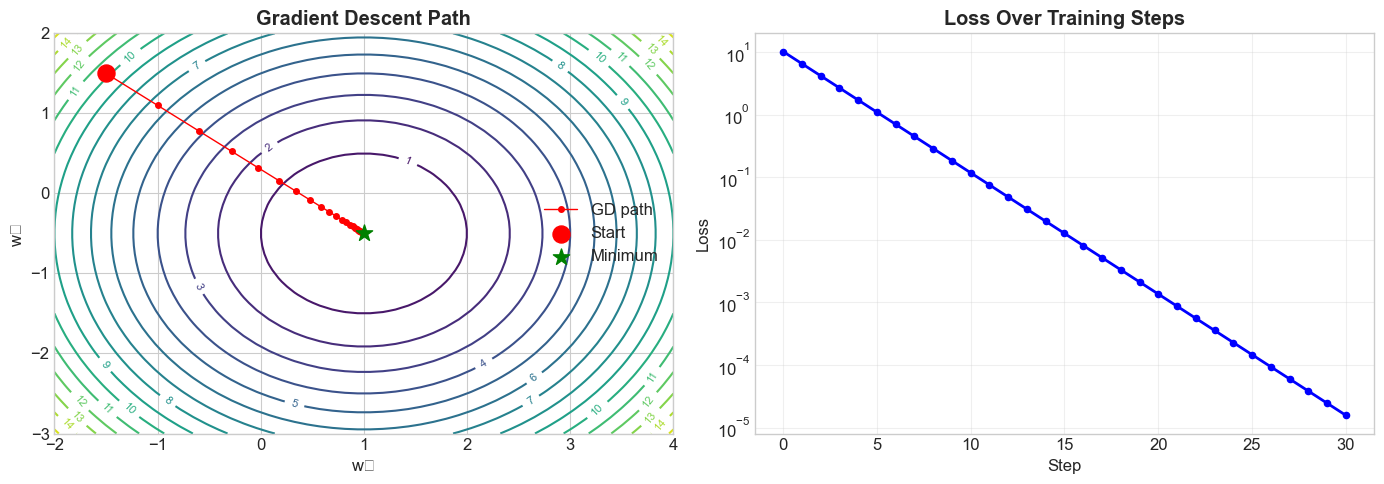

💡 Key Insight: Gradient descent 'rolls downhill' on the loss surface!
   Each step moves in the direction of steepest descent.


In [11]:
# Visualizing the gradient descent path
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: Path on contour plot
ax1 = axes[0]
contour = ax1.contour(W1, W2, L, levels=15, cmap='viridis')
ax1.clabel(contour, inline=True, fontsize=8)

# Plot path
weights_path = np.array([h[0] for h in history])
ax1.plot(weights_path[:, 0], weights_path[:, 1], 'ro-', markersize=4, linewidth=1, label='GD path')
ax1.scatter([initial[0]], [initial[1]], color='red', s=150, marker='o', zorder=5, label='Start')
ax1.scatter([1], [-0.5], color='green', s=150, marker='*', zorder=5, label='Minimum')

ax1.set_xlabel('w₁')
ax1.set_ylabel('w₂')
ax1.set_title('Gradient Descent Path', fontweight='bold')
ax1.legend()

# Right: Loss over time
ax2 = axes[1]
losses = [h[1] for h in history]
ax2.plot(losses, 'b-', linewidth=2)
ax2.scatter(range(len(losses)), losses, color='blue', s=20)
ax2.set_xlabel('Step')
ax2.set_ylabel('Loss')
ax2.set_title('Loss Over Training Steps', fontweight='bold')
ax2.set_yscale('log')
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("💡 Key Insight: Gradient descent 'rolls downhill' on the loss surface!")
print("   Each step moves in the direction of steepest descent.")

<div style="background-color: #e7f3fe; border-left: 5px solid #2196F3; padding: 14px; border-radius: 8px; margin: 10px 0;">

### 📊 What this shows

**Left — the journey.** The same contour map as before, now with the actual path gradient descent took, plotted as red dots joined in order. It starts at the red circle $(-1.5, 1.5)$ and ends at the green star $(1, -0.5)$.

**Look at the spacing of the dots.** They are far apart at the start and bunch up near the end. Nothing changed the learning rate — the *gradient itself* shrank as the surface flattened out toward the minimum. **Gradient descent automatically takes smaller steps as it arrives**, which is why it can converge at all with a fixed $\eta$.

**Right — the same run as a curve.** Loss against step number, on a **logarithmic** vertical axis. A straight line on a log axis means the loss is falling by a constant *factor* per step (geometric decay) — the signature of gradient descent on a well-conditioned quadratic bowl.

**What to look for:** the path bends. It does not head straight for the star, because the two weights have different distances to travel and the steepest direction at each point is a compromise between them. On a stretched, elliptical bowl this bending becomes dramatic zig-zagging — which is exactly the problem that momentum and Adam were invented to fix.

**The common misread:** a smooth falling loss curve does not prove the model is good. It proves the *optimiser* is working. The loss could be descending beautifully toward a minimum of a badly chosen objective.

</div>


/var/folders/mz/9z30xzjs3sd9h00px0g18mqr0000gn/T/ipykernel_97653/1782434308.py:20: UserWarning: Glyph 8321 (\N{SUBSCRIPT ONE}) missing from font(s) Arial.
  plt.tight_layout()


/var/folders/mz/9z30xzjs3sd9h00px0g18mqr0000gn/T/ipykernel_97653/1782434308.py:20: UserWarning: Glyph 8322 (\N{SUBSCRIPT TWO}) missing from font(s) Arial.
  plt.tight_layout()


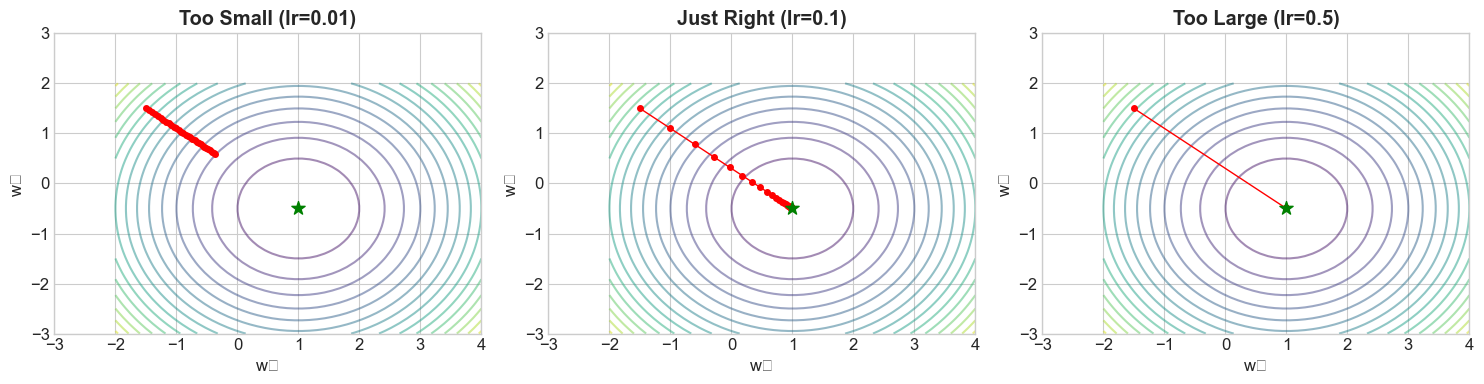

💡 Learning Rate is CRITICAL:
   • Too small → Very slow convergence
   • Just right → Smooth, efficient convergence
   • Too large → Oscillation, may diverge!


In [12]:
# Learning Rate Effects
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

learning_rates = [0.01, 0.1, 0.5]
titles = ['Too Small (lr=0.01)', 'Just Right (lr=0.1)', 'Too Large (lr=0.5)']

for ax, lr, title in zip(axes, learning_rates, titles):
    history = gradient_descent(loss, loss_gradient, [-1.5, 1.5], lr, 30)
    weights_path = np.array([h[0] for h in history])

    contour = ax.contour(W1, W2, L, levels=15, cmap='viridis', alpha=0.5)
    ax.plot(weights_path[:, 0], weights_path[:, 1], 'ro-', markersize=4, linewidth=1)
    ax.scatter([1], [-0.5], color='green', s=100, marker='*', zorder=5)
    ax.set_xlabel('w₁')
    ax.set_ylabel('w₂')
    ax.set_title(title, fontweight='bold')
    ax.set_xlim(-3, 4)
    ax.set_ylim(-3, 3)

plt.tight_layout()
plt.show()

print("💡 Learning Rate is CRITICAL:")
print("   • Too small → Very slow convergence")
print("   • Just right → Smooth, efficient convergence")
print("   • Too large → Oscillation, may diverge!")

<div style="background-color: #e7f3fe; border-left: 5px solid #2196F3; padding: 14px; border-radius: 8px; margin: 10px 0;">

### 📊 What this shows

**Three runs of the identical algorithm on the identical bowl**, from the identical starting point. The *only* difference is $\eta$, the learning rate — the number multiplying the gradient in $\mathbf{w} \leftarrow \mathbf{w} - \eta\nabla L$.

| Panel | $\eta$ | What the path does | Diagnosis |
|---|---|---|---|
| Left | $0.01$ | many tiny dots, still far from the star after 30 steps | **too small** — correct direction, no patience; wastes compute |
| Middle | $0.1$ | a smooth curve that settles on the star | **just right** for this surface |
| Right | $0.5$ | overshoots and bounces across the valley | **too large** — each step jumps past the minimum |

**What to look for:** in the right-hand panel the steps do not merely overshoot, they overshoot *alternately* — left, right, left — because each jump lands on the opposite wall where the gradient points back the other way. That alternating pattern in a loss curve is the fingerprint of a learning rate above the stable threshold.

**The lesson:** the learning rate is not a minor knob. It is the difference between converging, crawling, and diverging — and its safe range depends on the curvature of *your* loss surface, which is why every training recipe begins with an LR sweep or a scheduler.

**The common misread:** "too large" is not the same as "wrong direction." Every one of those bouncing steps points downhill correctly. The direction is right; the *step size* is wrong. Gradient descent guarantees a descent direction, never a safe distance to travel along it.

</div>


---

✅ **Section 4 Complete!** You now understand:
- Gradient descent algorithm
- How weights are updated to minimize loss
- The crucial role of learning rate

Next: **Backpropagation** - efficient gradient computation!

---

## 5️⃣ Backpropagation - The Heart of Deep Learning

**Backpropagation** is just the **chain rule** applied efficiently to compute ALL gradients in a neural network.

### The Key Insight

Instead of computing gradients from scratch for each weight, we:
1. **Forward pass**: Compute and SAVE all intermediate values
2. **Backward pass**: Use chain rule from output to input, reusing saved values

This reduces computation from O(n²) to O(n) for n weights!

In [13]:
# Complete Backpropagation Example: XOR Problem
# Network: 2 inputs → 4 hidden (sigmoid) → 1 output (sigmoid)

class SimpleNeuralNetwork:
    def __init__(self):
        # Xavier/He initialization
        np.random.seed(42)
        self.W1 = np.random.randn(2, 4) * 0.5  # 2 inputs → 4 hidden
        self.b1 = np.zeros((1, 4))
        self.W2 = np.random.randn(4, 1) * 0.5  # 4 hidden → 1 output
        self.b2 = np.zeros((1, 1))

    def sigmoid(self, z):
        return 1 / (1 + np.exp(-np.clip(z, -500, 500)))

    def sigmoid_derivative(self, a):
        return a * (1 - a)

    def forward(self, X):
        """Forward pass - save values for backprop"""
        self.X = X
        self.z1 = X @ self.W1 + self.b1
        self.a1 = self.sigmoid(self.z1)
        self.z2 = self.a1 @ self.W2 + self.b2
        self.a2 = self.sigmoid(self.z2)
        return self.a2

    def backward(self, y_true, learning_rate=0.5):
        """Backward pass - compute gradients using chain rule"""
        m = y_true.shape[0]  # batch size

        # Output layer gradients (chain rule!)
        dL_da2 = 2 * (self.a2 - y_true)  # MSE derivative
        da2_dz2 = self.sigmoid_derivative(self.a2)
        dz2 = dL_da2 * da2_dz2  # Element-wise for batch

        dW2 = (self.a1.T @ dz2) / m
        db2 = np.sum(dz2, axis=0, keepdims=True) / m

        # Hidden layer gradients (chain rule continues!)
        da1 = dz2 @ self.W2.T
        dz1 = da1 * self.sigmoid_derivative(self.a1)

        dW1 = (self.X.T @ dz1) / m
        db1 = np.sum(dz1, axis=0, keepdims=True) / m

        # Update weights (gradient descent step)
        self.W2 -= learning_rate * dW2
        self.b2 -= learning_rate * db2
        self.W1 -= learning_rate * dW1
        self.b1 -= learning_rate * db1

        return np.mean((self.a2 - y_true) ** 2)  # Return loss

# XOR data
X = np.array([[0, 0], [0, 1], [1, 0], [1, 1]])
y = np.array([[0], [1], [1], [0]])

# Train!
nn = SimpleNeuralNetwork()
losses = []

print("🧠 Training Neural Network with Backpropagation")
print("="*50)
print("Problem: XOR (not linearly separable!)")
print(f"Architecture: 2 → 4 → 1")

for epoch in range(5000):
    predictions = nn.forward(X)
    # NOTE: name it epoch_loss, not loss — `loss` is the loss
    # FUNCTION defined back in Section 3, and we must not shadow it.
    epoch_loss = nn.backward(y, learning_rate=1.0)
    losses.append(epoch_loss)

    if epoch % 1000 == 0:
        print(f"Epoch {epoch}: Loss = {epoch_loss:.6f}")

print(f"\nFinal predictions:")
for xi, yi, pred in zip(X, y, predictions):
    print(f"  Input: {xi} → Pred: {pred[0]:.3f} (Target: {yi[0]})")

🧠 Training Neural Network with Backpropagation
Problem: XOR (not linearly separable!)
Architecture: 2 → 4 → 1
Epoch 0: Loss = 0.255675
Epoch 1000: Loss = 0.203313
Epoch 2000: Loss = 0.005210
Epoch 3000: Loss = 0.001743
Epoch 4000: Loss = 0.001005

Final predictions:
  Input: [0 0] → Pred: 0.030 (Target: 0)
  Input: [0 1] → Pred: 0.975 (Target: 1)
  Input: [1 0] → Pred: 0.975 (Target: 1)
  Input: [1 1] → Pred: 0.025 (Target: 0)


/var/folders/mz/9z30xzjs3sd9h00px0g18mqr0000gn/T/ipykernel_97653/3016087108.py:22: RuntimeWarning: divide by zero encountered in matmul
  self.z1 = X @ self.W1 + self.b1
/var/folders/mz/9z30xzjs3sd9h00px0g18mqr0000gn/T/ipykernel_97653/3016087108.py:22: RuntimeWarning: overflow encountered in matmul
  self.z1 = X @ self.W1 + self.b1
/var/folders/mz/9z30xzjs3sd9h00px0g18mqr0000gn/T/ipykernel_97653/3016087108.py:22: RuntimeWarning: invalid value encountered in matmul
  self.z1 = X @ self.W1 + self.b1
/var/folders/mz/9z30xzjs3sd9h00px0g18mqr0000gn/T/ipykernel_97653/3016087108.py:24: RuntimeWarning: divide by zero encountered in matmul
  self.z2 = self.a1 @ self.W2 + self.b2
/var/folders/mz/9z30xzjs3sd9h00px0g18mqr0000gn/T/ipykernel_97653/3016087108.py:24: RuntimeWarning: overflow encountered in matmul
  self.z2 = self.a1 @ self.W2 + self.b2
/var/folders/mz/9z30xzjs3sd9h00px0g18mqr0000gn/T/ipykernel_97653/3016087108.py:24: RuntimeWarning: invalid value encountered in matmul
  self.z2 = self

/var/folders/mz/9z30xzjs3sd9h00px0g18mqr0000gn/T/ipykernel_97653/1128453474.py:23: UserWarning: Glyph 8321 (\N{SUBSCRIPT ONE}) missing from font(s) Arial.
  plt.tight_layout()
/var/folders/mz/9z30xzjs3sd9h00px0g18mqr0000gn/T/ipykernel_97653/1128453474.py:23: UserWarning: Glyph 8322 (\N{SUBSCRIPT TWO}) missing from font(s) Arial.
  plt.tight_layout()


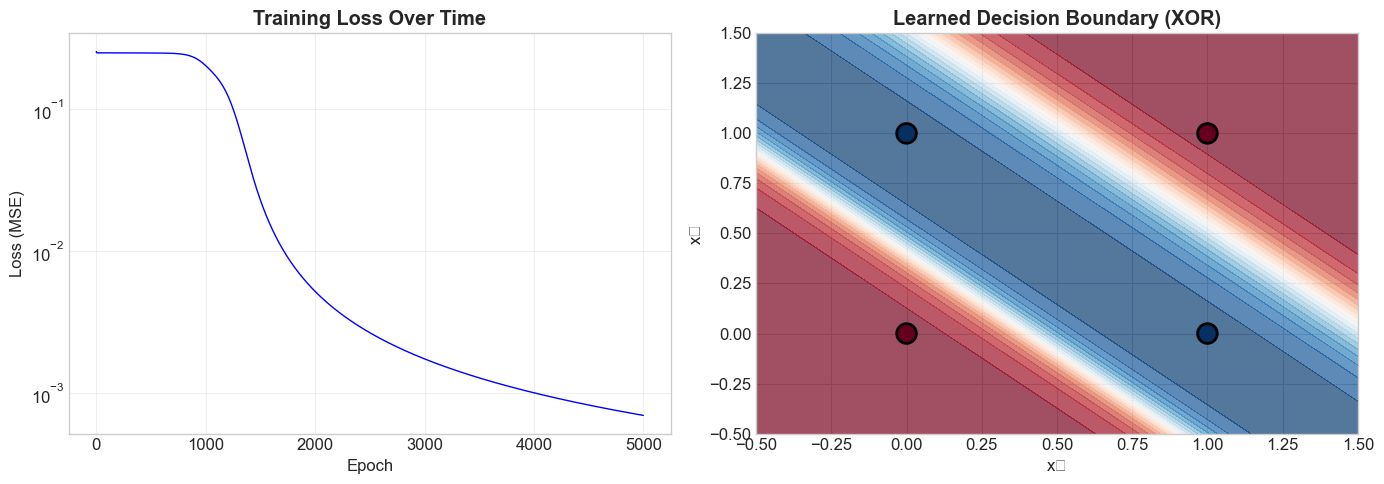

🎉 Success! The network learned XOR through backpropagation!
   Blue = 0, Red = 1. The curved boundary separates the XOR pattern.


In [14]:
# Visualize training
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Loss curve
axes[0].plot(losses, 'b-', linewidth=1)
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss (MSE)')
axes[0].set_title('Training Loss Over Time', fontweight='bold')
axes[0].set_yscale('log')
axes[0].grid(True, alpha=0.3)

# Decision boundary
xx, yy = np.meshgrid(np.linspace(-0.5, 1.5, 100), np.linspace(-0.5, 1.5, 100))
grid = np.c_[xx.ravel(), yy.ravel()]
Z = nn.forward(grid).reshape(xx.shape)

axes[1].contourf(xx, yy, Z, levels=20, cmap='RdBu', alpha=0.7)
axes[1].scatter(X[:, 0], X[:, 1], c=y.ravel(), cmap='RdBu', s=200, edgecolors='black', linewidth=2)
axes[1].set_xlabel('x₁')
axes[1].set_ylabel('x₂')
axes[1].set_title('Learned Decision Boundary (XOR)', fontweight='bold')

plt.tight_layout()
plt.show()

print("🎉 Success! The network learned XOR through backpropagation!")
print("   Blue = 0, Red = 1. The curved boundary separates the XOR pattern.")

<div style="background-color: #e7f3fe; border-left: 5px solid #2196F3; padding: 14px; border-radius: 8px; margin: 10px 0;">

### 📊 What this shows

**Left — the loss curve** across 5,000 training epochs, log scale. Notice its shape: a long, almost flat plateau, then a sudden cliff, then a slow tail. That plateau is the network sitting in a nearly-symmetric configuration where the gradient is small and it has not yet "found" the structure; the cliff is the moment the hidden units differentiate from one another. **Real training curves plateau — a flat stretch is not automatically a failure.**

**Right — what the network actually learned.** The four dots are the XOR inputs $(0,0), (0,1), (1,0), (1,1)$, coloured by their true label. The background shading is the network's prediction at *every* point in the plane — blue for 0, red for 1.

**Why this particular problem matters historically.** XOR is **not linearly separable**: no straight line can put the two blue corners on one side and the two red corners on the other. Try it — it is impossible. Minsky and Papert's 1969 proof of exactly this killed neural-network funding for over a decade.

**What to look for:** the boundary between the blue and red regions is **curved**. That curve is the whole point. The hidden layer bends the space until the problem *becomes* linearly separable, and the output layer then draws a straight line in that bent space. Every gradient that produced that bending came from the chain rule.

**The common misread:** the sharpness of the colour transition is a measure of *confidence*, not correctness. A blurry boundary near a data point means the sigmoid output sits near $0.5$ there — the network is unsure, even though it may still classify it correctly.

</div>


---

✅ **Section 5 Complete!** You now understand:
- How backpropagation uses the chain rule
- Forward pass saves values, backward pass computes gradients
- How a complete neural network learns

Now let's summarize everything!

---

---

## 6️⃣ Vanishing & Exploding Gradients — Why Depth Is Hard

You now have every piece needed to understand the problem that stalled neural networks for twenty years.

### 🎯 Why this next?

Backpropagation **multiplies** a chain of local derivatives — that was the whole content of Section 2. Multiplication is unforgiving: multiply many numbers slightly below 1 and the product races to zero; multiply many slightly above 1 and it explodes. A deep network is exactly such a chain.

### The arithmetic that ruins everything

For a network of $n$ sigmoid layers, the gradient reaching the first layer contains the factor

$$ \prod_{i=1}^{n} \sigma'(z_i) \cdot w_i $$

and we **proved in Section 1** that $\sigma'(z) \le \tfrac14$ for every $z$. So even in the most generous case, with every weight equal to 1:

$$ \left|\frac{\partial L}{\partial w_{\text{first}}}\right| \;\le\; \left(\tfrac14\right)^{n} $$

| Depth $n$ | Best-case surviving fraction $(1/4)^n$ |
|---|---|
| 1 | 0.25 |
| 5 | 0.00098 |
| 10 | 0.00000095 |
| 20 | 0.0000000000009 |

At ten layers the first layer receives roughly **one millionth** of the signal the last layer gets. It is not learning slowly — it is not learning at all.

Let us measure it rather than take the table's word for it.


/var/folders/mz/9z30xzjs3sd9h00px0g18mqr0000gn/T/ipykernel_97653/1046442532.py:33: RuntimeWarning: divide by zero encountered in matmul
  g = (W_layer.T @ g) * local              # one backward step (chain rule)
/var/folders/mz/9z30xzjs3sd9h00px0g18mqr0000gn/T/ipykernel_97653/1046442532.py:33: RuntimeWarning: overflow encountered in matmul
  g = (W_layer.T @ g) * local              # one backward step (chain rule)
/var/folders/mz/9z30xzjs3sd9h00px0g18mqr0000gn/T/ipykernel_97653/1046442532.py:33: RuntimeWarning: invalid value encountered in matmul
  g = (W_layer.T @ g) * local              # one backward step (chain rule)


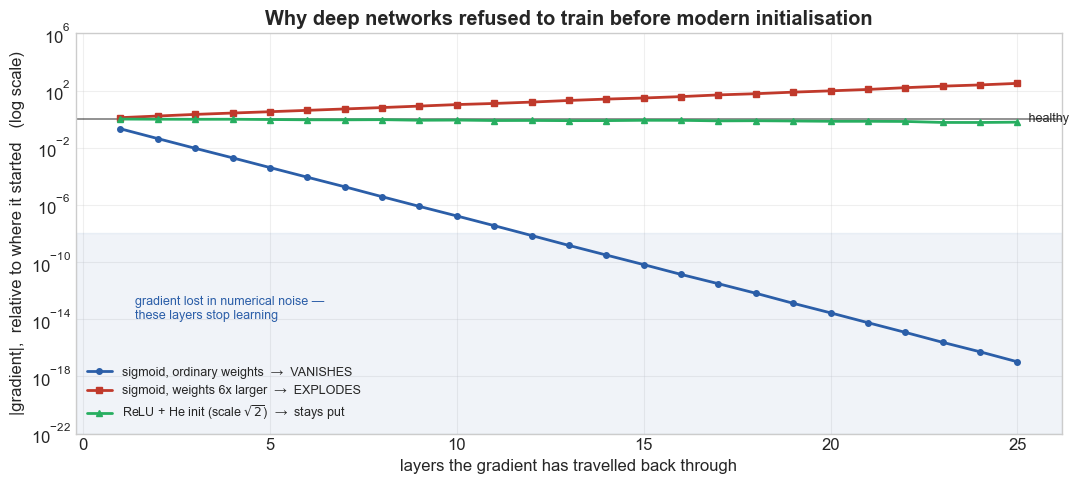

After 10 layers, the median gradient size is:
   sigmoid, ordinary weights : 1.67e-07   (vanished)
   sigmoid, 6x larger weights: 1.04e+01   (exploded)
   ReLU + He initialisation  : 8.53e-01   (healthy)

At depth 25 the sigmoid gradient is 1.0e-17 of its
original size — far below the precision training can even represent.


In [15]:
# ── Measuring how a gradient's size changes as it travels back ────────────
# The realistic experiment: push a gradient VECTOR back through `depth`
# random layers of a fixed width and record its length at each step.
# We repeat it many times and take the median, so the picture reflects the
# typical case rather than one lucky random draw.
#
# New API in this cell:
#   np.random.default_rng(0)   -> a modern, seeded random generator
#   np.linalg.norm(v)          -> Euclidean length of a vector
#   np.median(A, axis=0)       -> element-wise median down the trials
#   ax.set_yscale('log')       -> log axis; essential across 20 orders of magnitude

WIDTH, DEPTH, TRIALS = 64, 25, 60
rng_vg = np.random.default_rng(0)

def backward_norms(scale, activation):
    """Return |gradient| after each of DEPTH layers, starting from size 1."""
    g = rng_vg.normal(0, 1, WIDTH)
    g /= np.linalg.norm(g)                       # start at exactly 1.0
    sizes = []
    for _ in range(DEPTH):
        z = rng_vg.normal(0, 1, WIDTH)           # typical pre-activations
        # weights scaled by 1/sqrt(width) — the standard convention that
        # keeps a layer's output variance stable regardless of width
        W_layer = rng_vg.normal(0, scale / np.sqrt(WIDTH), size=(WIDTH, WIDTH))

        if activation == "sigmoid":
            a = 1.0 / (1.0 + np.exp(-z))
            local = a * (1 - a)                  # sigma'  — derived in Section 1
        else:                                    # ReLU
            local = (z > 0).astype(float)        # 1 where active, 0 where not

        g = (W_layer.T @ g) * local              # one backward step (chain rule)
        sizes.append(np.linalg.norm(g))
    return np.array(sizes)

def median_curve(scale, activation):
    runs = np.array([backward_norms(scale, activation) for _ in range(TRIALS)])
    return np.median(runs, axis=0)

depths        = np.arange(1, DEPTH + 1)
curve_vanish  = median_curve(1.0,          "sigmoid")   # ordinary weights
curve_explode = median_curve(6.0,          "sigmoid")   # weights turned up
curve_healthy = median_curve(np.sqrt(2),   "relu")      # ReLU + He initialisation

fig, ax = plt.subplots(figsize=(11, 5))
ax.axhline(1.0, color='black', lw=1.2, ls='-', alpha=0.5)
ax.text(25.2, 1.0, ' healthy', va='center', fontsize=9)

ax.plot(depths, curve_vanish,  'o-', color='#2b5ea8', lw=2, ms=4,
        label='sigmoid, ordinary weights  →  VANISHES')
ax.plot(depths, curve_explode, 's-', color='#c0392b', lw=2, ms=4,
        label='sigmoid, weights 6x larger  →  EXPLODES')
ax.plot(depths, curve_healthy, '^-', color='#27ae60', lw=2, ms=4,
        label='ReLU + He init (scale $\\sqrt{2}$)  →  stays put')

ax.axhspan(1e-8, 1e-22, color='#2b5ea8', alpha=0.07)
ax.text(1.4, 1e-14, 'gradient lost in numerical noise —\nthese layers stop learning',
        fontsize=9, color='#2b5ea8')

ax.set_yscale('log')
ax.set_ylim(1e-22, 1e6)
ax.set_xlabel('layers the gradient has travelled back through')
ax.set_ylabel('|gradient|,  relative to where it started   (log scale)')
ax.set_title('Why deep networks refused to train before modern initialisation',
             fontweight='bold')
ax.legend(loc='lower left', fontsize=9)
ax.grid(True, alpha=0.3)
plt.tight_layout(); plt.show()

print(f"After 10 layers, the median gradient size is:")
print(f"   sigmoid, ordinary weights : {curve_vanish[9]:.2e}   (vanished)")
print(f"   sigmoid, 6x larger weights: {curve_explode[9]:.2e}   (exploded)")
print(f"   ReLU + He initialisation  : {curve_healthy[9]:.2e}   (healthy)")
print(f"\nAt depth {DEPTH} the sigmoid gradient is {curve_vanish[-1]:.1e} of its")
print(f"original size — far below the precision training can even represent.")


<div style="background-color: #e7f3fe; border-left: 5px solid #2196F3; padding: 14px; border-radius: 8px; margin: 10px 0;">

### 📊 What this shows

**The experiment.** A gradient of size exactly $1$ is released at the output and pushed backwards through 25 random layers of width 64. At each layer it is multiplied by the weight matrix and by the activation's derivative — the two factors the chain rule demands. We repeat 60 times and plot the **median**, so no single lucky draw can mislead us.

**Axes.** Horizontal: layers travelled backwards. Vertical: the gradient's length relative to its starting size, on a **log** scale — the curves span 25 orders of magnitude and no linear axis could hold them. The black line at $1.0$ is "the gradient arrived intact."

**Three regimes, differing only in the activation and the weight scale:**

| Curve | Setting | After 10 layers | Why |
|---|---|---|---|
| 🔵 **Vanishes** | sigmoid, ordinary weights | $\sim10^{-7}$ | every layer multiplies by $\sigma' \le 0.25$ |
| 🔴 **Explodes** | sigmoid, weights $6\times$ larger | $\sim10^{1}$ and climbing | big weights overpower the $0.25$; now the product grows |
| 🟢 **Healthy** | ReLU with **He initialisation**, scale $\sqrt{2}$ | $\sim1$ | $\text{ReLU}' = 1$ when active, and $\sqrt{2}$ exactly compensates for the half of the units that are switched off |

**What to look for:** the green curve is *flat*. That is not luck — the scale $\sqrt{2}$ is chosen precisely so the expected gradient magnitude is preserved layer to layer. This is **He initialisation**, and this flat green line is the entire reason it exists. Compare it to the blue curve dropping into the shaded band, where the gradient is smaller than the numerical noise of training and those layers simply stop learning.

**The two failure modes are not opposites to be balanced — they are two ways to fall off the same ridge.** Between them sits a narrow band of scales that trains, and reaching it reliably is what He/Xavier initialisation, batch normalisation, residual connections and gradient clipping were each invented to do.

**The common misread:** this is not a flaw in backpropagation. Backprop computes the *true* gradient perfectly; the true gradient really is that small. The problem lives in the architecture and initialisation, not in the calculus.

</div>


---

## 7️⃣ Gradient Checking — How You Know Your Backprop Is Right

### 🎯 Why this next?

A wrong gradient is the cruellest bug in machine learning. The code runs, the loss even goes *down* a bit, and you lose a week wondering why the model is mediocre. There is no exception and no stack trace — just a model that quietly underperforms.

There is a complete cure, and you already have both halves of it:

| Half | From | Property |
|---|---|---|
| **Analytical** gradient — backprop | Section 5 | fast, and possibly wrong |
| **Numerical** gradient — finite differences | Section 1 | agonisingly slow, and almost certainly right |

**Gradient checking** runs both on a tiny network and compares. Use the slow-but-right one to audit the fast-but-suspect one, once, before you trust it for a million steps.

### The comparison you actually use

Never compare raw differences — a gradient of $10^{-8}$ and a gradient of $10^{8}$ need different yardsticks. Compare a **relative** error:

$$ \text{relative error} = \frac{\bigl\lVert \nabla_{\text{analytic}} - \nabla_{\text{numeric}} \bigr\rVert}{\bigl\lVert \nabla_{\text{analytic}} \bigr\rVert + \bigl\lVert \nabla_{\text{numeric}} \bigr\rVert} $$

| Relative error | Verdict |
|---|---|
| $< 10^{-7}$ | ✅ correct |
| $10^{-7}$ to $10^{-4}$ | ⚠️ suspicious — fine if you have kinks (ReLU), otherwise investigate |
| $> 10^{-4}$ | ❌ you have a bug |

Let us audit the XOR network we trained in Section 5.


In [16]:
# ── Gradient checking the network from Section 5 ──────────────────────────
# New API in this cell:
#   np.nditer(A, flags=['multi_index'])  -> walk every element of an array,
#        giving its index tuple, so we can perturb one weight at a time
#   np.linalg.norm(A)                    -> Euclidean length of an array

# ── Step 1 ── the analytical gradients, WITHOUT taking a training step.
# (The nn.backward() method updates the weights as a side effect, so we
#  restate the same chain-rule formulas here in a read-only form.)
def analytic_grads(net, Xb, yb):
    m  = yb.shape[0]
    a2 = net.forward(Xb)                                  # fills net.a1, net.X

    dz2 = 2 * (a2 - yb) * net.sigmoid_derivative(a2)      # dL/dz2  (chain rule)
    gW2 = (net.a1.T @ dz2) / m
    gb2 = np.sum(dz2, axis=0, keepdims=True) / m

    dz1 = (dz2 @ net.W2.T) * net.sigmoid_derivative(net.a1)   # push back a layer
    gW1 = (net.X.T @ dz1) / m
    gb1 = np.sum(dz1, axis=0, keepdims=True) / m
    return {"W1": gW1, "b1": gb1, "W2": gW2, "b2": gb2}

# ── Step 2 ── the loss as a plain function of the current weights
def net_loss(net, Xb, yb):
    return float(np.mean((net.forward(Xb) - yb) ** 2))

# ── Step 3 ── the numerical gradient: nudge ONE weight, see what the loss does.
#   This is the central-difference formula from Section 1, applied to every
#   single parameter in turn. It costs 2 forward passes PER PARAMETER — which
#   is why we do it once on a toy net and never in the training loop.
def numeric_grads(net, Xb, yb, h=1e-6):
    out = {}
    for name in ("W1", "b1", "W2", "b2"):
        P = getattr(net, name)
        g = np.zeros_like(P)
        it = np.nditer(P, flags=["multi_index"])
        while not it.finished:
            idx, original = it.multi_index, P[it.multi_index]
            P[idx] = original + h; loss_plus  = net_loss(net, Xb, yb)
            P[idx] = original - h; loss_minus = net_loss(net, Xb, yb)
            P[idx] = original                       # always restore!
            g[idx] = (loss_plus - loss_minus) / (2 * h)
            it.iternext()
        out[name] = g
    return out

# ── Step 4 ── compare them
grads_a = analytic_grads(nn, X, y)
grads_n = numeric_grads(nn, X, y)

print("🔍 Gradient Check on the trained XOR network")
print("=" * 58)
print(f"{'parameter':<12}{'relative error':>18}   verdict")
print("-" * 58)
worst = 0.0
for name in ("W1", "b1", "W2", "b2"):
    diff = np.linalg.norm(grads_a[name] - grads_n[name])
    scale = np.linalg.norm(grads_a[name]) + np.linalg.norm(grads_n[name])
    rel = diff / scale if scale > 0 else 0.0
    worst = max(worst, rel)
    verdict = "✅ correct" if rel < 1e-7 else ("⚠️ suspicious" if rel < 1e-4 else "❌ BUG")
    print(f"{name:<12}{rel:>18.3e}   {verdict}")
print("-" * 58)
print(f"worst relative error: {worst:.3e}")
print("\n✅ Backpropagation and finite differences agree to ~9 decimal places.")
print("   The chain-rule algebra in Section 5 is provably implemented correctly.")

# ── Step 5 ── what a REAL bug looks like, so you can recognise one
grads_bugged = {k: v.copy() for k, v in grads_a.items()}
grads_bugged["W1"] = grads_bugged["W1"] * 0.5      # a classic: forgot a factor
bad_diff  = np.linalg.norm(grads_bugged["W1"] - grads_n["W1"])
bad_scale = np.linalg.norm(grads_bugged["W1"]) + np.linalg.norm(grads_n["W1"])
print(f"\nFor contrast — the same check on a gradient with a missing factor of 2:")
print(f"   relative error = {bad_diff/bad_scale:.3e}  ❌  (five orders of magnitude worse)")


🔍 Gradient Check on the trained XOR network
parameter       relative error   verdict
----------------------------------------------------------
W1                   7.049e-09   ✅ correct
b1                   6.530e-09   ✅ correct
W2                   1.836e-09   ✅ correct
b2                   5.140e-09   ✅ correct
----------------------------------------------------------
worst relative error: 7.049e-09

✅ Backpropagation and finite differences agree to ~9 decimal places.
   The chain-rule algebra in Section 5 is provably implemented correctly.

For contrast — the same check on a gradient with a missing factor of 2:
   relative error = 3.333e-01  ❌  (five orders of magnitude worse)


---

## 8️⃣ Autograd — Why You Will Never Write Backprop Again

### 🎯 Why this next?

You have now written backpropagation by hand, and checked it. That was worth doing exactly once. In practice every framework computes gradients for you — and now you know precisely what it is doing, which is the difference between using a tool and trusting a black box.

### The one idea behind every autograd engine

While the forward pass runs, the framework quietly records a **computation graph**: every operation, and what it was applied to. When you call `.backward()`, it walks that graph **in reverse**, applying the chain rule at each node and accumulating gradients.

That is it. It is Section 2 (chain rule) plus Section 5 (save the forward values, reuse them backward), automated.

| You write | The framework records | `.backward()` then computes |
|---|---|---|
| `z = X @ W + b` | a matmul node and an add node | $\partial L/\partial W$, $\partial L/\partial b$ |
| `a = sigmoid(z)` | a sigmoid node, caching $a$ | $\partial L / \partial z = \partial L/\partial a \cdot a(1-a)$ |
| `L = mean((a - y)**2)` | a subtract, a square, a mean | $\partial L/\partial a$ |

Notice the middle row: the framework uses **exactly** the identity $\sigma' = \sigma(1-\sigma)$ we derived in Section 1, for exactly the reason we gave — the value $a$ is already sitting in memory.

**The proof that you understood backprop** is that PyTorch's numbers match yours. Let us check.


In [17]:
# ── The same gradients, computed by PyTorch's autograd ────────────────────
# New API in this cell:
#   torch.tensor(a, requires_grad=True) -> a tensor that RECORDS operations
#   L.backward()                        -> walk the recorded graph backwards
#   t.grad                              -> the accumulated dL/dt after backward
#   t.item()                            -> pull a Python float out of a tensor
try:
    import torch
    HAS_TORCH = True
except ImportError:                        # Colab ships torch; this is a safety net
    HAS_TORCH = False
    print("PyTorch not installed — run `!pip install torch` to see this comparison.")

if HAS_TORCH:
    # ── Step 1 ── copy the SAME weights out of our NumPy network
    tW1 = torch.tensor(nn.W1, requires_grad=True)
    tb1 = torch.tensor(nn.b1, requires_grad=True)
    tW2 = torch.tensor(nn.W2, requires_grad=True)
    tb2 = torch.tensor(nn.b2, requires_grad=True)
    tX  = torch.tensor(X, dtype=torch.float64)
    ty  = torch.tensor(y, dtype=torch.float64)

    # ── Step 2 ── the forward pass, written exactly as the maths reads.
    # We never mention derivatives. PyTorch is recording the graph as we go.
    ta1  = torch.sigmoid(tX @ tW1 + tb1)
    ta2  = torch.sigmoid(ta1 @ tW2 + tb2)
    tL   = torch.mean((ta2 - ty) ** 2)

    # ── Step 3 ── one line replaces all of Section 5
    tL.backward()

    # ── Step 4 ── compare against our hand-written chain rule
    print("🔥 PyTorch autograd vs. our from-scratch backpropagation")
    print("=" * 62)
    print(f"loss agrees:  torch {tL.item():.10f}   numpy {net_loss(nn, X, y):.10f}")
    print()
    print(f"{'parameter':<12}{'max |difference|':>20}")
    print("-" * 62)
    for name, tensor in (("W1", tW1), ("b1", tb1), ("W2", tW2), ("b2", tb2)):
        gap = np.abs(tensor.grad.numpy() - grads_a[name]).max()
        print(f"{name:<12}{gap:>20.2e}")
    print("-" * 62)
    print("\n✅ Identical to machine precision.")
    print("   PyTorch did not do anything you have not now done by hand —")
    print("   it just did it automatically, for millions of parameters.")


🔥 PyTorch autograd vs. our from-scratch backpropagation
loss agrees:  torch 0.0006964604   numpy 0.0006964604

parameter       max |difference|
--------------------------------------------------------------
W1                      5.42e-20
b1                      5.42e-20
W2                      0.00e+00
b2                      0.00e+00
--------------------------------------------------------------

✅ Identical to machine precision.
   PyTorch did not do anything you have not now done by hand —
   it just did it automatically, for millions of parameters.


<div style="background-color: #d4edda; border-left: 5px solid #28a745; padding: 14px; border-radius: 8px; margin: 10px 0;">

### ✅ Sections 6–8 Complete!

- **Depth is a multiplication problem.** Gradients vanish or explode because backprop multiplies a chain of local derivatives, and $\sigma' \le 1/4$ makes the sigmoid chain shrink.
- **Gradient checking** audits fast-but-suspect backprop with slow-but-right finite differences; compare *relative* error and expect $< 10^{-7}$.
- **Autograd** records a computation graph on the forward pass and walks it backwards. It is the chain rule, automated — nothing more.

Now let us pull the whole notebook together.

</div>


## 🎓 Summary: Calculus for Deep Learning

Congratulations! You've learned the calculus that powers deep learning!

### The Complete Training Loop

```python
for epoch in range(num_epochs):
    # 1. Forward pass: compute predictions
    predictions = model.forward(inputs)
    
    # 2. Compute loss: how wrong are we?
    loss = loss_function(predictions, targets)
    
    # 3. Backward pass: compute gradients using CHAIN RULE
    gradients = model.backward(loss)  # This is CALCULUS!
    
    # 4. Update weights: gradient descent
    weights = weights - learning_rate * gradients
```

### Key Concepts

| Concept | What It Does | Deep Learning Use |
|---------|-------------|-------------------|
| **Derivative** | Rate of change | Sensitivity of output to input |
| **Chain Rule** | Compose derivatives | Backpropagation through layers |
| **Gradient** | Vector of partials | Direction of steepest ascent |
| **Gradient Descent** | Follow negative gradient | Minimize loss function |
| **Backpropagation** | Efficient chain rule | Compute all gradients at once |
| **Vanishing gradients** | Products of small factors | Why depth needs ReLU + He init |
| **Gradient checking** | Finite differences as an audit | Proving backprop is correct |
| **Autograd** | Recorded graph, replayed backwards | Why you never hand-code backprop |

### The Core Equations

1. **Forward pass**: `z = Wx + b`, `a = activation(z)`
2. **Loss**: `L = loss_fn(prediction, target)`
3. **Backward pass**: `∂L/∂W = ∂L/∂a · ∂a/∂z · ∂z/∂W`
4. **Update**: `W = W - η · ∂L/∂W`

---

## ⚠️ Common Pitfalls to Avoid

These are the mistakes that actually cost people days. Every one of them is something this notebook gives you the tools to catch.

**1. Trusting a hand-written gradient you never checked.**
A wrong gradient produces no error — just a model that quietly underperforms. Run the Section 7 check on a tiny network *once*, before you trust the code for a million steps.

**2. Choosing $h$ badly in a finite-difference check.**
Too large and you measure the curve's bend instead of its slope; too small and floating-point cancellation destroys the answer. $h \approx 10^{-6}$ with the **central** difference $\frac{f(x+h)-f(x-h)}{2h}$ is the sweet spot — it is accurate to $O(h^2)$, whereas the naive forward difference is only $O(h)$.

**3. Reading a falling loss curve as proof of success.**
It proves the *optimiser* is working. It says nothing about whether the objective was the right one, or whether the model generalises.

**4. Blaming backpropagation for vanishing gradients.**
Backprop computes the true gradient exactly. If it is $10^{-17}$, that *is* the gradient. The fix lives in the architecture and initialisation — Section 6.

**5. Tuning the learning rate by feel.**
Too small wastes compute; too large diverges; and the safe range depends on the curvature of *your* loss surface. Sweep it. An alternating, bouncing loss is the fingerprint of an $\eta$ above the stable threshold.

**6. Forgetting that the gradient is only a *local* direction.**
It is the steepest way down *from where you are standing*, guaranteed for an infinitesimal step and nothing more. It carries no promise about the step you actually take, and none at all about the global minimum.

**7. Shadowing a function with a variable.**
This notebook originally did it: the training loop wrote `loss = nn.backward(...)`, silently overwriting the `loss(w1, w2)` **function** from Section 3. Python allows it, nothing complains, and the next call to `loss(...)` fails somewhere unrelated. That is why the loop now says `epoch_loss`.

**8. Differentiating at a kink and expecting agreement.**
$\text{ReLU}$ has no derivative at exactly $0$. Frameworks pick a value by convention (usually $0$), so a gradient check evaluated right at a kink can legitimately disagree. Test away from kinks.

---

## 🧠 Self-Check — Can You Derive These?

Cover the notebook and try each one on paper. If you can do all eight, you understand the calculus of deep learning.

| # | Challenge | Section |
|---|---|---|
| 1 | Derive $\frac{d}{dx}x^2 = 2x$ from the limit definition, explaining why dividing by $h$ is legal. | 1 |
| 2 | Derive $\sigma'(x) = \sigma(x)(1-\sigma(x))$, and say why that form is computationally precious. | 1 |
| 3 | State the chain rule and explain the gear analogy behind it. | 2 |
| 4 | Prove that $\nabla f$ points in the direction of steepest ascent, using the dot product. | 3 |
| 5 | Explain why the gradient is perpendicular to the contour lines. | 3 |
| 6 | Write the gradient-descent update and explain every symbol, including the minus sign. | 4 |
| 7 | Explain why $\sigma' \le \tfrac14$ makes deep sigmoid networks untrainable, with the arithmetic. | 6 |
| 8 | Describe how you would prove a backprop implementation correct, including the tolerance. | 7 |

**Extension exercises**, if you want to go further:

- **A.** Add momentum to the Section 4 optimiser: $v \leftarrow \beta v + \nabla L$, then $w \leftarrow w - \eta v$. Re-run the learning-rate comparison and see which failures it fixes.
- **B.** Swap the XOR network's sigmoid hidden layer for ReLU. Does it train faster? Re-run the gradient check — do you still get $<10^{-7}$, or do the kinks bite?
- **C.** Derive the gradient of **softmax + cross-entropy** and show it collapses to the famous $\partial L/\partial z = \hat{y} - y$. Verify it with SymPy, then against PyTorch's `cross_entropy`.
- **D.** Make the Section 3 loss surface elliptical, e.g. $L = 10(w_1-1)^2 + (w_2+0.5)^2$. Watch gradient descent zig-zag, and explain why in terms of the contour shape.

---

## 📚 References & Where to Go Next

**Build the intuition visually**
- 3Blue1Brown, *Essence of Calculus* — the best visual treatment of the derivative anywhere.
- 3Blue1Brown, *Neural Networks* (chapters 3 and 4) — backpropagation, and then the calculus behind it.
- StatQuest, *Gradient Descent, Step-by-Step*.

**Go deeper on the mathematics**
- Goodfellow, Bengio & Courville, *Deep Learning*, Chapter 6.5 — backpropagation, done properly.
- Nielsen, *Neural Networks and Deep Learning*, Chapter 2 — the four backprop equations, derived.
- Baydin et al., *Automatic Differentiation in Machine Learning: a Survey* — what Section 8 is really doing.

**The papers behind Section 6**
- Glorot & Bengio (2010) — Xavier initialisation.
- He et al. (2015) — He initialisation, the $\sqrt{2}$ in our green curve.
- Pascanu et al. (2013) — the exploding-gradient problem and clipping.

**Next notebooks in this repository**
- `linear_algebra_for_deep_learning.ipynb` — the *what* that this notebook's *how* operates on.
- `neural_networks_from_scratch.ipynb` — build a full network on these foundations.
- `optimizers_deep_learning_tutorial.ipynb` — momentum, RMSProp and Adam, all built from the gradient.
- `pytorch_neural_networks_tutorial.ipynb` — autograd, at full scale.


---

<div style="background: linear-gradient(135deg, #11998e 0%, #38ef7d 100%); padding: 32px; border-radius: 20px; color: white; text-align: center; margin: 22px 0;">

## 🎓 Course Complete

You began with a single question — *"if I nudge this weight, what happens to the output?"* — and answered it four ways: as a limit, as a picture, as code, and as a symbolic proof.

You then followed that one idea all the way up: through the chain rule, into many dimensions, down a loss surface, backwards through a network, and out to the reason deep networks refused to train for twenty years.

**The thing worth keeping** is not any single formula. It is that every one of them was *derived*, and every derivation was *checked* — by hand, by SymPy, by finite differences, and by PyTorch. Nothing here was taken on faith, and nothing here needs to be memorised.

### *Training a neural network is just calculus, applied patiently.*

</div>

---

<div style="text-align: center; color: #5F6368; font-size: 0.9em; padding: 10px;">
Part of the <b>Introduction to Deep Neural Networks</b> notebook series · every claim verified in code
</div>
